### Step 1 : Introduction to CNNs

Convolutional Neural Network, neural network designed for analyzing visual data. This model learn to 'see' the world by identifying patterns.
It recognize patterns with a grid-like structure.

The model process images by passing them through multiple layers, each of them identifying a feature (edges, lines, ...). The deeper layers recognize more complex patterns (shapes, whole objects, ...).

The layers :
- Convolutional layer : identifying simple feature (straight edge, curve, color, ...)
- Activation layer : reviewing of the map created by the cconvolutional layer, it keeps the strong signals and get rid of the weak ones. It ensures that only the important features are kept, preventing noise from cluttering the process
- Pooling layer : summarize the findings from small patches of the feature map, reducing the size of the data
- Fully connected layer : looks at the high-level combination features (whiskers, ...), draws a conclusion (cat or dog)

### Step 2: Dataset Exploration

In [23]:
# imports
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

base_dir = "cats_and_dogs_filtered"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "validation")

In [24]:
# Image count
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(train_dir)
val_counts = count_images(val_dir)

print("Train : ", train_counts)
print("Validation : ", val_counts)

Train :  {'cats': 1000, 'dogs': 1000}
Validation :  {'cats': 500, 'dogs': 500}


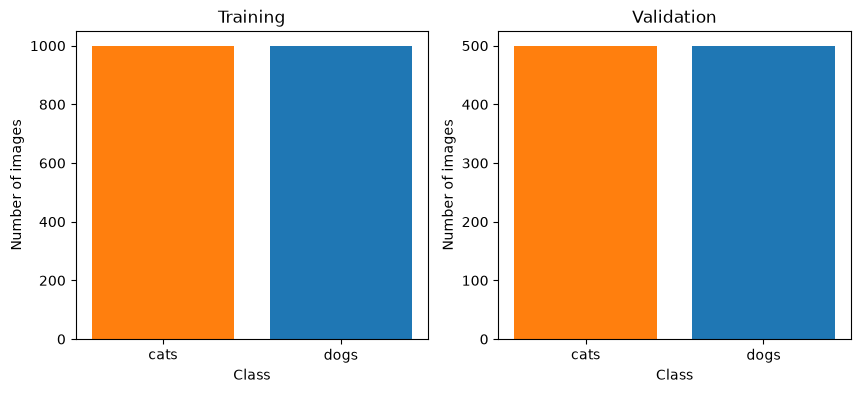

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, counts, title in zip(
    axes,
    [train_counts, val_counts],
    ["Training", "Validation"]
):
    ax.bar(
        counts.keys(),
        counts.values(),
        color=["tab:orange", "tab:blue"]
    )

    ax.set_title(title)
    ax.set_ylabel("Number of images")
    ax.set_xlabel("Class")

plt.show()

In [26]:
# Image parameters
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training", 
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    validation_split=0.2,
    subset="validation", 
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


### Step 3: Build Your CNN Model

In [27]:
model = tf.keras.Sequential([

    # Normalize pixel values to [0, 1] range
    tf.keras.layers.Rescaling(1./255, input_shape=(150, 150, 3)), 

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,994,305 (7.61 MB)

 Trainable params: 1,994,305 (7.61 MB)

 Non-trainable params: 0 (0.00 B)

### Step 4: Train the Model

### Step 5: Evaluate the Model on the test set